现实生活中，大多数数据都不服从独立同分布（independently and identically distribution）

循环神经网络可以很好地处理序列信息，通过引入状态变化量存储过去的信息和当前的输入，从而确定当前的输出


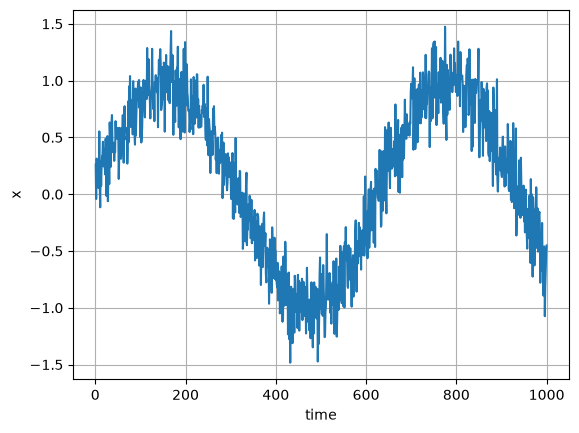

In [4]:
import torch
import matplotlib.pyplot as plt

T = 1000
time = torch.arange(1,T+1,dtype=torch.float32)
x = torch.sin(0.01*time) + torch.normal(0,0.2,(T,))

plt.plot(time.numpy(), x.numpy())
plt.xlabel("time")
plt.ylabel("x")
plt.grid(True)
plt.show()

In [5]:
"通过马尔可夫模型进行预测"

from torch.utils.data import TensorDataset, DataLoader

tau = 4
features = torch.zeros((T, tau), dtype=torch.float32)

for t in range(tau):
    features[t, tau-t-1 : tau] = x[0 : t + 1]
for t in range(tau, T):
    features[t, :] = x[t - tau + 1 : t + 1]

labels = x.reshape(-1, 1)

batch_size, n_train = 16, 600

train_feats = features[:n_train]
train_labels = labels[:n_train]

train_dataset = TensorDataset(train_feats, train_labels)

train_iter = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False,
    num_workers=0,
)

In [6]:
"搭建 MLP 预测网络"

import torchvision
from torch import nn

def get_net():
    net = nn.Sequential(nn.Linear(4, 10),
                        nn.ReLU(),
                        nn.Linear(10, 1))
    return net

loss = nn.MSELoss()

def evaluate_loss(net, data_iter, loss):
    net.eval()
    total_loss, cnt = 0, 0
    with torch.no_grad():
        for X, y in data_iter:
            total_loss += loss(net(X), y).sum().item()
            cnt += X.shape[0]
    return total_loss / cnt

def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()

        train_avg_loss = evaluate_loss(net, train_iter, loss)
        print(f'epoch {epoch + 1}, loss: {train_avg_loss:.6f}')

net = get_net()
for layer in net.modules():
    if isinstance(layer, nn.Linear):
        nn.init.xavier_uniform_(layer.weight)
        nn.init.zeros_(layer.bias)

train(net, train_iter, loss, 5, 0.01)

epoch 1, loss: 0.001736
epoch 2, loss: 0.001231
epoch 3, loss: 0.000616
epoch 4, loss: 0.000262
epoch 5, loss: 0.000097


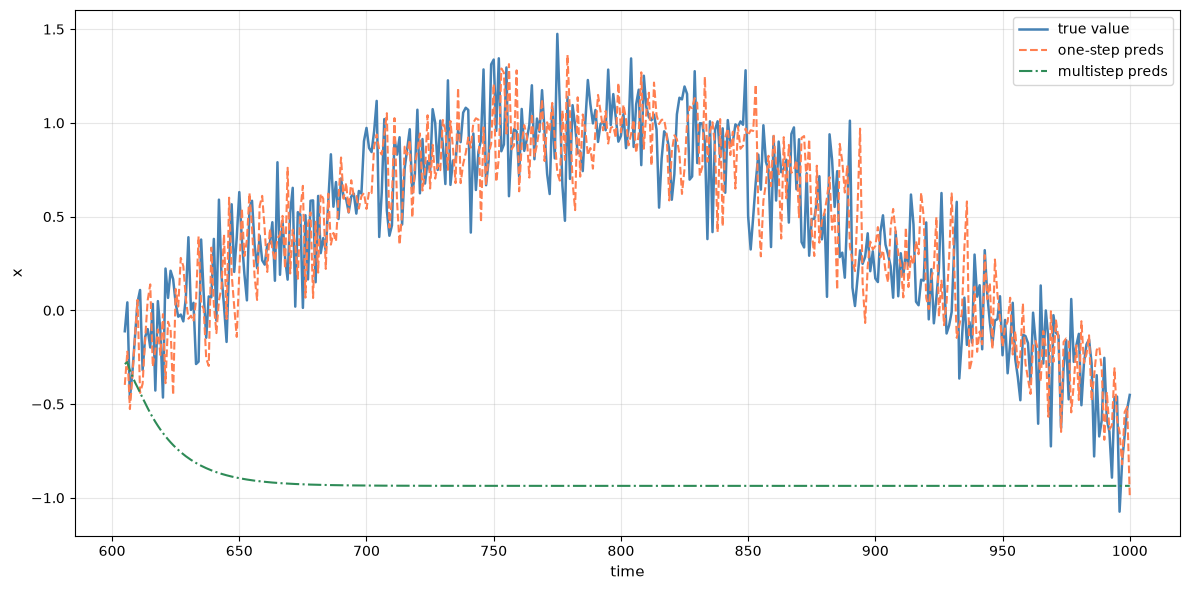

In [ ]:
"预测"

from torch import nn

net.eval()
device = next(net.parameters()).device

time_axis = time[tau:].numpy()
true_seq = x[tau:].numpy()

# 测试区间长度与对应时间轴
test_len = len(time_axis) - n_train
test_time = time_axis[n_train:]
test_true = true_seq[n_train:]

# ========== 单步预测 ==========
with torch.no_grad(): # 关闭梯度计算
    all_pred_single = net(features.to(device)).cpu().numpy().flatten()
test_pred_single = all_pred_single[n_train: n_train + test_len]

# ========== 自回归多步预测  ==========
# 初始窗口：训练集最后一组真实窗口
last_window = features[n_train - 1].clone().to(device)
pred_recursive = []

with torch.no_grad():
    for _ in range(test_len):
        # 用当前窗口预测下一个时刻的值
        next_val = net(last_window.unsqueeze(0)).item()
        pred_recursive.append(next_val)
        # 窗口滚动：丢弃最旧值，把刚预测出的值作为新的历史输入
        last_window = torch.cat([last_window[1:], torch.tensor([next_val], device=device)])

test_pred_recursive = torch.tensor(pred_recursive).numpy()

plt.figure(figsize=(12, 6))

# 真实值
plt.plot(test_time, test_true, color='steelblue', linewidth=1.8, label='true value')
# 单步预测
plt.plot(test_time, test_pred_single, color='coral', linewidth=1.5, linestyle='--', label='one-step preds')
# 自回归多步预测
plt.plot(test_time, test_pred_recursive, color='seagreen', linewidth=1.5, linestyle='-.', label='multistep preds')

plt.xlabel('time', fontsize=11)
plt.ylabel('x', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()